In [9]:
import pandas as pd
import matplotlib.pyplot as plt


In [10]:
path_baseline = "../data/analytics/model_results/CEN-TRAF/con_exog/baseline/validation_metrics_all_steps_baseline.csv"
df_base_line = pd.read_csv(path_baseline)
df_base_line["model"] = df_base_line["model"].replace({"NaiveByLag": "Baseline"})
df_base_line.head()

,step,model,rmse,mae,mse,r2,wmape,stepwise_wmape
0,1,Baseline,4.250596,2.707869,18.067565,0.356507,0.347365,"{""1"": 0.3473653507757769}"
1,2,Baseline,5.128691,3.354201,26.303469,0.063178,0.430277,"{""1"": 0.3460015061119401, ""2"": 0.5133821232882..."
2,3,Baseline,5.704870,3.808603,32.545536,-0.159139,0.488567,"{""1"": 0.31476824517282587, ""2"": 0.523685297275..."
3,4,Baseline,6.004708,4.057372,36.056521,-0.284186,0.520480,"{""1"": 0.3439542581080587, ""2"": 0.4998809069486..."
4,5,Baseline,6.113311,4.246518,37.372577,-0.331059,0.544743,"{""1"": 0.33358014978030426, ""2"": 0.534372213370..."


In [11]:
path_lstm = "../data/analytics/model_results/CEN-TRAF/con_exog/lstm/validation_metrics_all_steps_direct.csv"
df_lstm = pd.read_csv(path_lstm)
df_lstm.head()


,step,model,rmse,mae,mse,r2,wmape,stepwise_wmape
0,1,LSTM,2.487200,1.506122,6.186166,0.779674,0.193205,"{""1"": 0.1932053505954507}"
1,2,LSTM,3.064579,2.155354,9.391647,0.665508,0.276489,"{""1"": 0.26109766797006756, ""2"": 0.291666112138..."
2,3,LSTM,3.530047,2.471875,12.461233,0.556182,0.317092,"{""1"": 0.2964930396426083, ""2"": 0.3143861597696..."
3,4,LSTM,3.232965,2.215439,10.452065,0.627740,0.284196,"{""1"": 0.23360429951778733, ""2"": 0.257489682593..."
4,5,LSTM,3.641678,2.627572,13.261820,0.527668,0.337065,"{""1"": 0.3077856044036955, ""2"": 0.3203497080271..."


In [12]:
path_direct = "../data/analytics/model_results/CEN-TRAF/con_exog/direct/validation_metrics_all_steps_direct.csv"
df_direct = pd.read_csv(path_direct)
df_direct["model"] = df_direct["model"].replace(
    {"LGBM": "LGBM direct", "XGBoost": "XGBoost direct"}
)
df_direct.head()

,step,model,rmse,mae,mse,r2,wmape,stepwise_wmape
0,1,LGBM direct,3.052833,2.024111,9.319787,0.668067,0.259653,"{""1"": 0.25965288818597204}"
1,1,XGBoost direct,3.549164,2.367246,12.596566,0.551362,0.303670,"{""1"": 0.3036702746589725}"
2,2,LGBM direct,3.259413,2.212891,10.623772,0.621625,0.283870,"{""1"": 0.2650568764235958, ""2"": 0.3024209846066..."
3,2,XGBoost direct,3.645984,2.469595,13.293200,0.526550,0.316800,"{""1"": 0.3055680510467731, ""2"": 0.3278751157890..."
4,3,LGBM direct,3.370486,2.299682,11.360175,0.595397,0.295003,"{""1"": 0.2519044398662406, ""2"": 0.3120805167029..."


In [13]:
path_simple = (
    "../data/analytics/model_results/CEN-TRAF/con_exog/validation_metrics_all_steps.csv"
)
df = pd.read_csv(path_simple)
df["model"] = df["model"].replace(
    {"LGBM": "LGBM recursive", "XGBoost": "XGBoost recursive"}
)


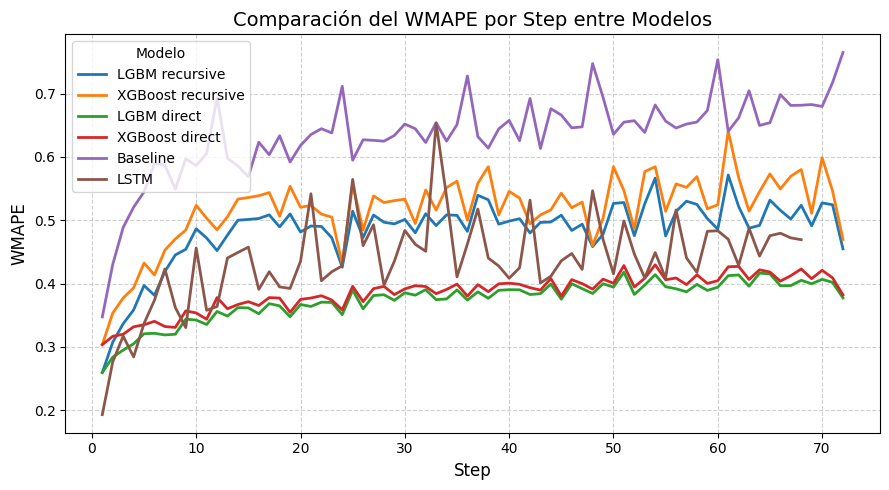

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Unir los dos DataFrames ---
df_all = pd.concat([df, df_direct, df_base_line, df_lstm], ignore_index=True)

# --- Graficar las tres líneas ---
plt.figure(figsize=(9, 5))

for model in df_all["model"].unique():
    subset = df_all[df_all["model"] == model]
    plt.plot(subset["step"], subset["wmape"], marker="", linewidth=2, label=model)

# --- Personalizar ---
plt.title("Comparación del WMAPE por Step entre Modelos", fontsize=14)
plt.xlabel("Step", fontsize=12)
plt.ylabel("WMAPE", fontsize=12)
plt.legend(title="Modelo", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()

plt.show()
